<a href="https://colab.research.google.com/github/omega-u20/SmartCare-HospitalManagement/blob/main/Task7_Explainable_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 07 – Explainable AI Analysis


## 0. Mount Google Drive and Load Saved Model

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DATA_FOLDER = '/content/drive/MyDrive/CCS3440 - Asg 2'
MODEL_FOLDER = f'{DATA_FOLDER}/models'

Mounted at /content/drive


In [ ]:
!pip install shap -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

random_forest = joblib.load(f'{MODEL_FOLDER}/random_forest.joblib')
scaler = joblib.load(f'{MODEL_FOLDER}/scaler.joblib')
feature_columns = joblib.load(f'{MODEL_FOLDER}/feature_columns.joblib')
numeric_cols = joblib.load(f'{MODEL_FOLDER}/numeric_columns.joblib')

print('Model loaded: Random Forest')
print('Number of input features:', len(feature_columns))

Model loaded: Random Forest
Number of input features: 58


## 1. Rebuild the Same Test Set

Same preprocessing and `random_state=42` split as Tasks 05 and 06, so the patients we explain here are the same held-out test patients used for evaluation.

In [ ]:
df = pd.read_csv(f'{DATA_FOLDER}/smartcare_ai_dataset_1000.csv')
df['room_type'] = df['room_type'].fillna('Not Admitted')
df = df.drop_duplicates()

df_model = df.drop(columns=['record_id', 'patient_id', 'no_show', 'disease_risk_level'])

df_model['appointment_date'] = pd.to_datetime(df_model['appointment_date'])
df_model['appointment_month'] = df_model['appointment_date'].dt.month
df_model['appointment_dayofweek'] = df_model['appointment_date'].dt.dayofweek
df_model = df_model.drop(columns=['appointment_date'])

df_model['missed_appointment_rate'] = np.where(
    df_model['previous_appointments'] > 0,
    df_model['missed_previous_appointments'] / df_model['previous_appointments'], 0)
df_model['is_hypertensive'] = ((df_model['systolic_bp'] >= 140) | (df_model['diastolic_bp'] >= 90)).astype(int)
df_model['avg_charge_per_treatment'] = np.where(
    df_model['treatments_count'] > 0,
    df_model['total_bill_lkr'] / df_model['treatments_count'], df_model['total_bill_lkr'])

categorical_cols = ['gender', 'blood_group', 'department', 'diagnosis', 'room_type',
                     'payment_status', 'payment_method', 'appointment_status']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

X = df_model[feature_columns]
y = df_model['readmitted_30_days']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

X_test_scaled = X_test.copy()
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print('Test set shape:', X_test_scaled.shape)

Test set shape: (200, 58)


## 2. Why SHAP?

We chose **SHAP** over plain feature importance or LIME for a specific reason. Random Forest's built-in `feature_importances_` (used briefly in Task 05) only tells us which features matter *on average across the whole model* . It can't tell us why one specific patient got flagged as high-risk. SHAP can explain **individual predictions** as well as overall patterns using a game-theory approach that fairly distributes credit for a prediction across all input features. This matters for a healthcare tool. A doctor doesn't just want to know "missed appointments matter in general" . They want to know "why did *this* patient get flagged."

We use `TreeExplainer`, which is specifically optimised for tree-based models like Random Forest (much faster than the general-purpose SHAP explainer).

In [ ]:
explainer = shap.TreeExplainer(random_forest)
shap_values = explainer.shap_values(X_test_scaled)

# For binary classification, shap_values can be a list [class_0, class_1] or a single 3D array
# depending on the SHAP/scikit-learn version. We standardise to the 'Readmitted' (class 1) values.
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_class1 = shap_values[:, :, 1]
else:
    shap_values_class1 = shap_values

print('SHAP values shape:', shap_values_class1.shape)

SHAP values shape: (200, 58)


## 3. Global Explainability – Which Features Matter Most Overall?

The summary plot shows every feature's impact across all 200 test patients. Each dot is one patient. The further right, the more that feature pushed the prediction *toward* readmission. The further left, the more it pushed away. Colour shows whether the feature's value was high (red) or low (blue) for that patient.

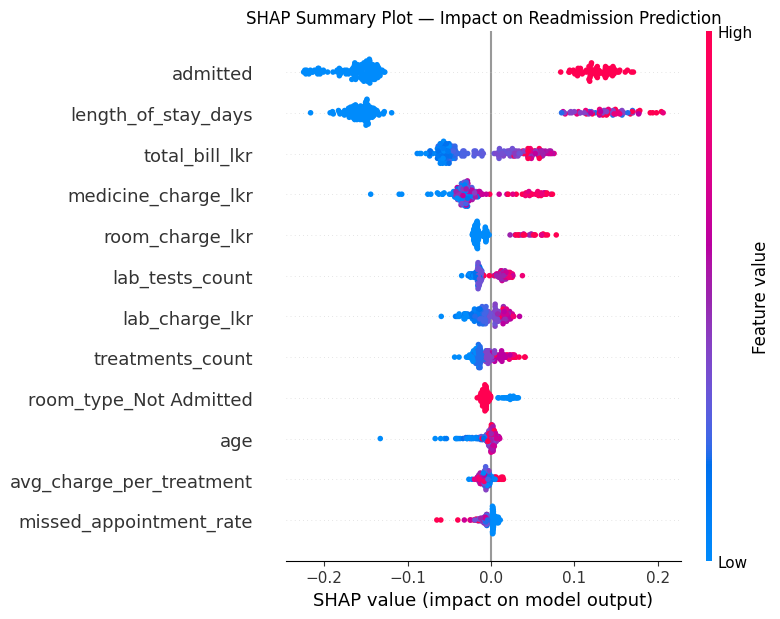

In [ ]:
plt.figure()
shap.summary_plot(shap_values_class1, X_test_scaled, show=False, max_display=12)
plt.title('SHAP Summary Plot — Impact on Readmission Prediction')
plt.tight_layout()
plt.show()

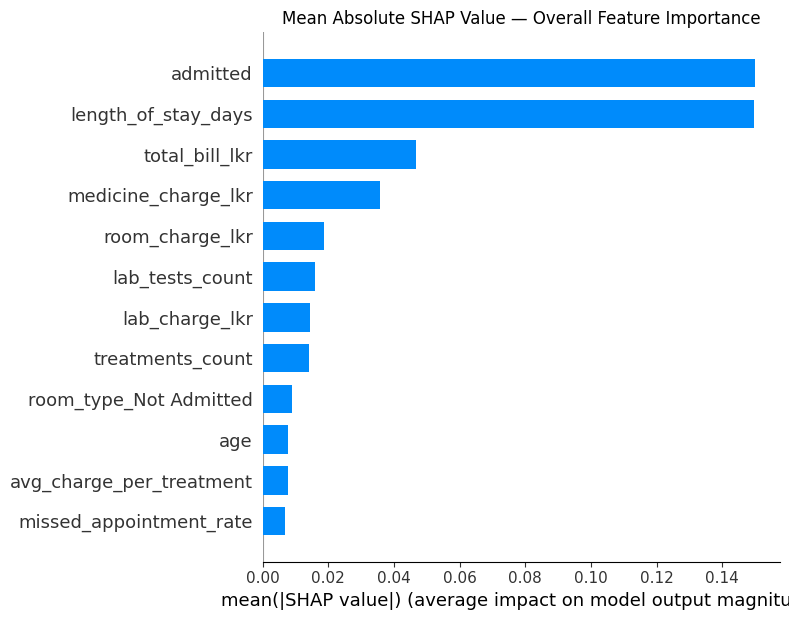

In [ ]:
plt.figure()
shap.summary_plot(shap_values_class1, X_test_scaled, plot_type='bar', show=False, max_display=12)
plt.title('Mean Absolute SHAP Value — Overall Feature Importance')
plt.tight_layout()
plt.show()

**Insight:** The results show `admitted` and `length_of_stay_days` as by far the two most influential features overall, followed by billing-related columns (`total_bill_lkr`, `medicine_charge_lkr`, `room_charge_lkr`) and testing/treatment counts. This makes clinical sense. Whether a patient was admitted at all and for how long is a strong signal of how serious their original condition was  and more serious original episodes are more likely to lead to a readmission within 30 days. The billing features track closely behind which is expected since they are largely driven by admission and length of stay. In the summary plot, red dots (high feature values) clustering on the right for `length_of_stay_days` means **the longer a patient stayed, the more the model Pushes its prediction toward "will be readmitted"**. An intuitive and clinically sensible pattern for the model to have learned.

## 4. Local Explainability – Explaining One Individual Patient

This is where SHAP goes beyond simple feature importance: explaining a **single prediction**, patient by patient. We pick one patient the model correctly flagged as high-risk and one it correctly flagged as low-risk and show exactly which features drove each decision.

In [ ]:
y_pred = random_forest.predict(X_test_scaled)
y_proba = random_forest.predict_proba(X_test_scaled)[:, 1]

# Find a correctly-predicted high-risk patient and a correctly-predicted low-risk patient
high_risk_idx = np.where((y_pred == 1) & (y_test.values == 1))[0][0]
low_risk_idx = np.where((y_pred == 0) & (y_test.values == 0))[0][0]

print(f'High-risk example: row {high_risk_idx}, predicted probability of readmission = {y_proba[high_risk_idx]:.2f}')
print(f'Low-risk example: row {low_risk_idx}, predicted probability of readmission = {y_proba[low_risk_idx]:.2f}')

High-risk example: row 1, predicted probability of readmission = 0.76
Low-risk example: row 0, predicted probability of readmission = 0.01


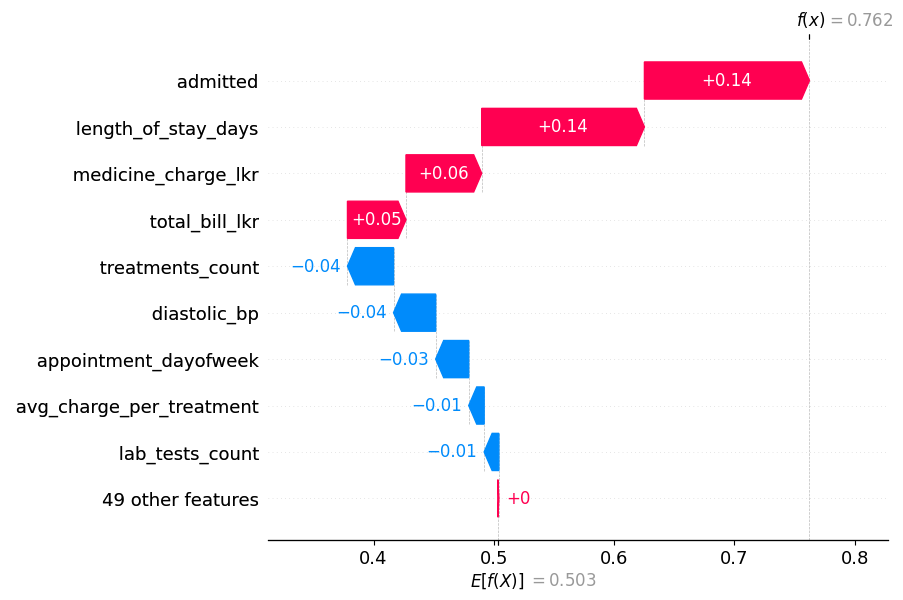

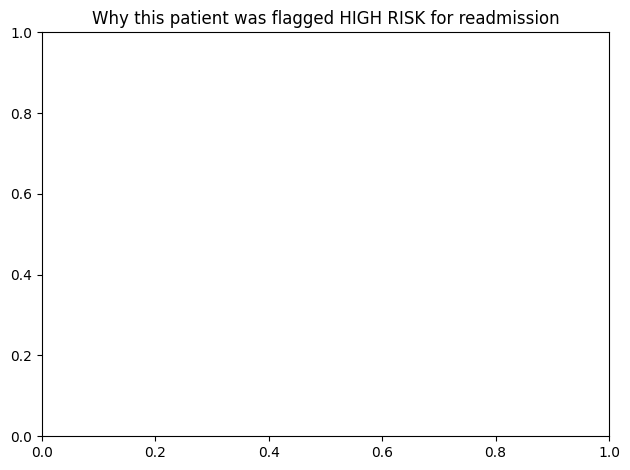

In [ ]:
expected_value = explainer.expected_value
expected_value_class1 = expected_value[1] if isinstance(expected_value, (list, np.ndarray)) and len(np.shape(expected_value)) > 0 and np.shape(expected_value)[0] > 1 else expected_value

plt.figure()
shap.plots._waterfall.waterfall_legacy(
    expected_value_class1, shap_values_class1[high_risk_idx], X_test_scaled.iloc[high_risk_idx], max_display=10)
plt.title('Why this patient was flagged HIGH RISK for readmission')
plt.tight_layout()
plt.show()

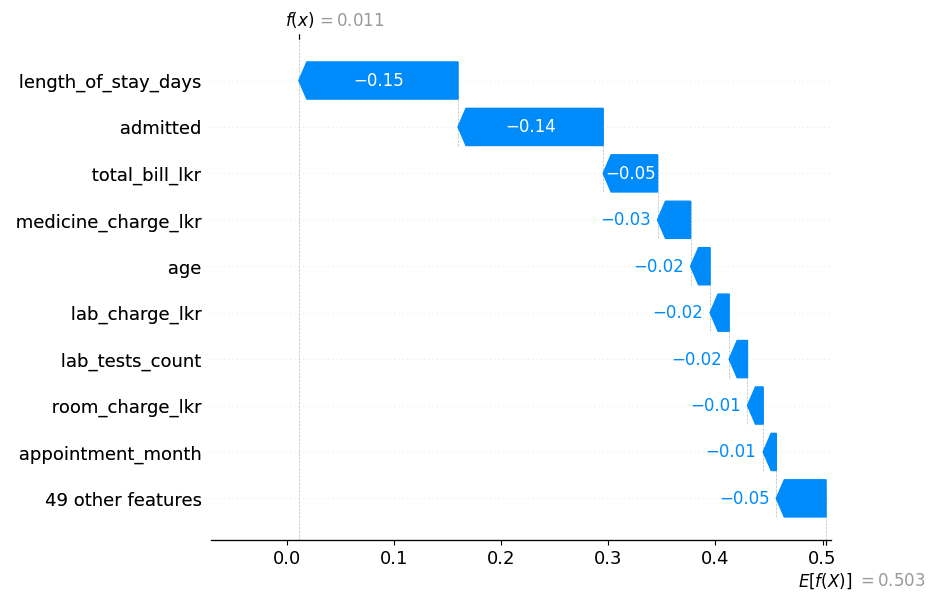

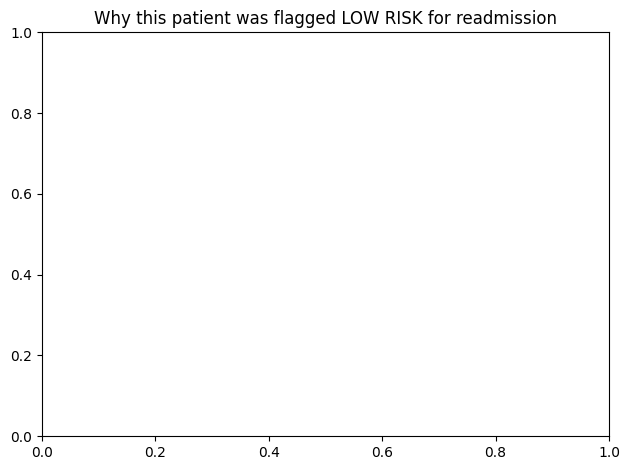

In [ ]:
plt.figure()
shap.plots._waterfall.waterfall_legacy(
    expected_value_class1, shap_values_class1[low_risk_idx], X_test_scaled.iloc[low_risk_idx], max_display=10)
plt.title('Why this patient was flagged LOW RISK for readmission')
plt.tight_layout()
plt.show()

**Insight:** The waterfall plots show, feature by feature, how the model moved from its baseline average prediction to the final probability for each individual patient. Features shown in red pushed the prediction higher (toward readmission), features in blue pushed it lower. This is exactly the kind of explanation a clinician could use in practice. Instead of just seeing "78% risk", they can see *which specific factors* (e.g. high previous admissions, elevated blood sugar) drove that number for that particular patient making the prediction actionable rather than a black box.

## 5. Feature Dependence – How Does One Feature Affect the Prediction?

A dependence plot zooms into a single feature and shows how its value relates to its SHAP impact and whether that relationship changes depending on another feature (shown by colour).

<Figure size 640x480 with 0 Axes>

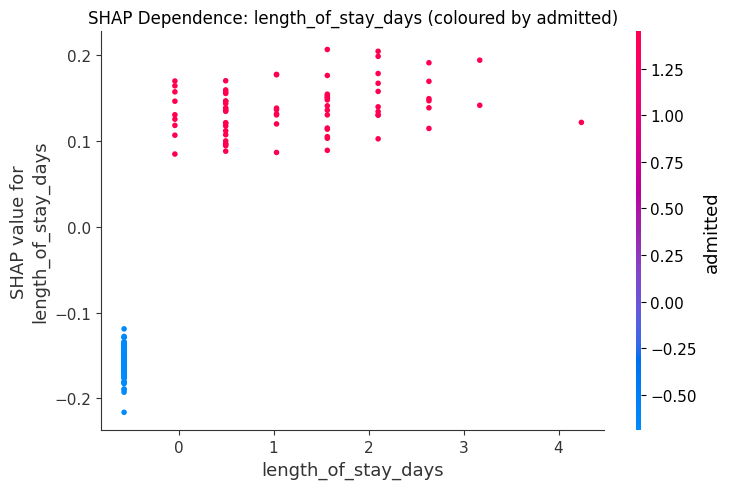

In [ ]:
plt.figure()
shap.dependence_plot('length_of_stay_days', shap_values_class1, X_test_scaled,
                      interaction_index='admitted', show=False)
plt.title('SHAP Dependence: length_of_stay_days (coloured by admitted)')
plt.tight_layout()
plt.show()

**Insight:** This plot shows how the SHAP impact of `length_of_stay_days` changes across its range and whether patients who were also `admitted` (shown by colour) get an amplified push toward the "readmitted" prediction. This kind of interaction is exactly what a simple correlation table can't show us .Correlation only measures straight-line relationships between two variables and the target while SHAP dependence plots reveal how two features combine to jointly influence a prediction.

## 6. Discussion: Transparency and Ethical Implications

**Important features and prediction reasoning.** Across the global and local explanations, the model relies most heavily on **admission status and length of stay** (`admitted`, `length_of_stay_days`), followed by **billing-related columns** and **testing/treatment counts**. This is clinically sensible. Whether and how long a patient was admitted is a strong proxy for how serious their original condition was and more serious episodes are more likely to lead to a 30-day readmission. This is reassuring .The model is not relying on an arbitrary or spurious pattern in the data.

**Transparency.** SHAP lets us move from "the model says 76% risk" to "the model says 76% risk *because of these five specific factors, in this direction with this magnitude*." This is the difference between a black-box tool clinicians would reasonably be wary of and a decision-support tool they can inspect, question and ultimately trust or override based on their own expertise.

**Ethical implications to consider:**
- **Fairness across patient groups.** We should check whether the model's errors are evenly spread across groups such as age, gender, or payment method rather than concentrated in one group . A model that is less accurate for a particular demographic could reinforce existing healthcare inequities. This kind of fairness audit is a natural extension of this notebook.
- **Financial features as predictors.** Billing-related columns (`total_bill_lkr`, `medicine_charge_lkr`, `room_charge_lkr`) rank among the most influential features. Using cost-related information to predict clinical risk raises a fairness question. Because these charges are themselves largely driven by `admitted`/`length_of_stay_days`, they are likely acting as a proxy for admission severity rather than independently linking payment ability to risk . But this distinction should be verified and clearly explained to Hospital management rather than assumed.
- **Human-in-the-loop use.** Given even a well-performing model still gets some predictions wrong (see Task 06's confusion matrices), this tool should support clinical judgement, not replace it. A predicted "high risk" should trigger closer review by a clinician, not an automatic, unreviewed action.
- **Explaining to patients.** Because SHAP can produce a plain-language, per-patient explanation, the hospital could, if desired, communicate to a patient in understandable terms *why* they've been flagged for extra follow-up care, supporting informed consent and patient trust rather than an opaque "the computer said so."

## 7. Save Explainability Outputs

In [ ]:
# Save mean absolute SHAP value per feature as a simple reference table for the technical report
mean_abs_shap = pd.DataFrame({
    'feature': X_test_scaled.columns,
    'mean_abs_shap_value': np.abs(shap_values_class1).mean(axis=0)
}).sort_values('mean_abs_shap_value', ascending=False).reset_index(drop=True)

mean_abs_shap.to_csv(f'{DATA_FOLDER}/shap_feature_importance.csv', index=False)
print('Saved: shap_feature_importance.csv')
mean_abs_shap.head(10)

Saved: shap_feature_importance.csv


,feature,mean_abs_shap_value
0,admitted,0.150097
1,length_of_stay_days,0.149689
2,total_bill_lkr,0.046698
3,medicine_charge_lkr,0.035882
4,room_charge_lkr,0.018562
5,lab_tests_count,0.015874
6,lab_charge_lkr,0.014324
7,treatments_count,0.014101
8,room_type_Not Admitted,0.008780
9,age,0.007790
